In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv("../data/processed/store_daily_sales.csv")

In [3]:
df.head()

,Store,Date,Sales
0,1,2013-01-02,5530
1,1,2013-01-03,4327
2,1,2013-01-04,4486
3,1,2013-01-05,4997
4,1,2013-01-07,7176


In [5]:
df["Sales"].describe()

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

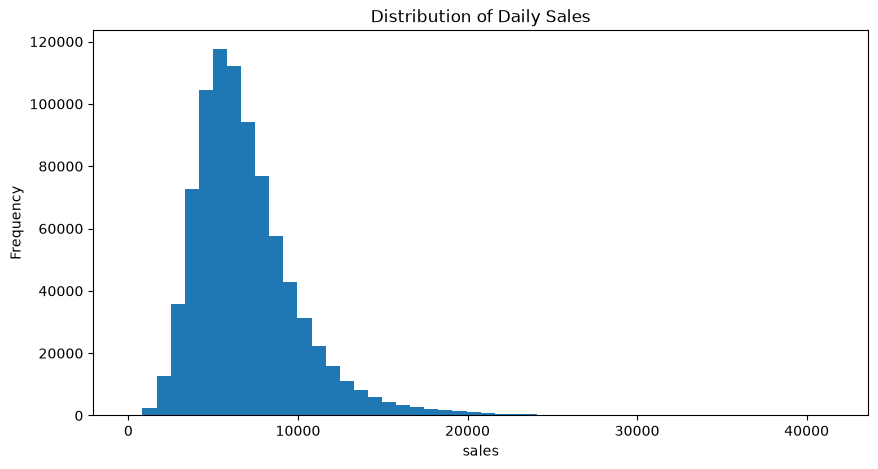

In [7]:
plt.figure(figsize=(10,5))
plt.hist(df["Sales"], bins = 50)
plt.xlabel("sales")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Sales")
plt.show()

In [13]:
df["Date"] = pd.to_datetime(df["Date"])
daily_sales= (df.groupby("Date")["Sales"]
             .sum()
             .reset_index()
             )
daily_sales.head()

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


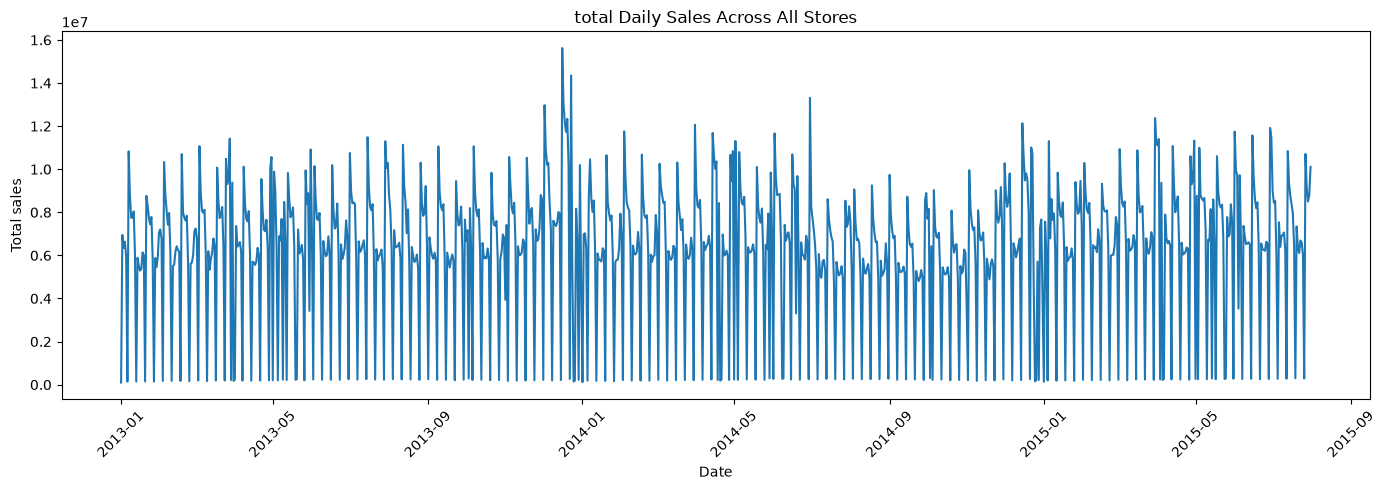

In [19]:
plt.figure(figsize=(14,5))
plt.plot(daily_sales["Date"], daily_sales["Sales"])

plt.xlabel("Date")
plt.ylabel("Total sales")
plt.title("total Daily Sales Across All Stores")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

The daily total sales show strong fluctuations over time.
Repeated sharp drops indicate a recurring weekly/closure pattern in store operations.
Sales also show occasional high-demand spikes, suggesting that calendar, promotion,
or other contextual factors may influence demand.

In [21]:
df["Month"] = df["Date"].dt.month

In [22]:
monthly_sales = (df.groupby("Month")["Sales"]
                 .mean()
                 .reset_index()
                )

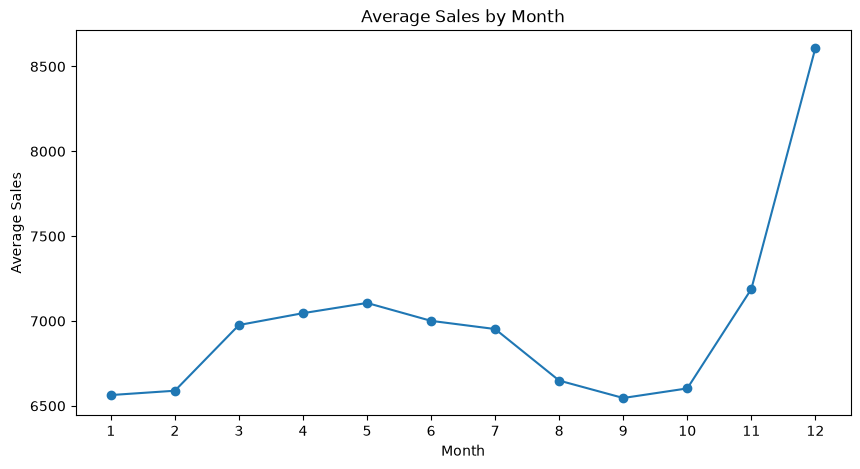

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.title("Average Sales by Month")

plt.xticks(range(1, 13))

plt.show()

### Monthly Seasonality Observation

Average sales vary across months. Sales generally increase during
March to May, decline during August to October, and rise again in
November and December. December shows the highest average sales,
indicating a potential seasonal demand pattern.

In [30]:
df["DayOfWeek"] = df["Date"].dt.day_name()

In [31]:
df[["Date", "DayOfWeek"]].head()

,Date,DayOfWeek
0,2013-01-02,Wednesday
1,2013-01-03,Thursday
2,2013-01-04,Friday
3,2013-01-05,Saturday
4,2013-01-07,Monday


In [33]:
weekday_sales = (
    df.groupby("DayOfWeek")["Sales"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

weekday_sales

,DayOfWeek,Sales
0,Monday,8216.073074
1,Tuesday,7088.113656
2,Wednesday,6728.122978
3,Thursday,6767.310159
4,Friday,7072.677012
5,Saturday,5874.840238
6,Sunday,8224.723908


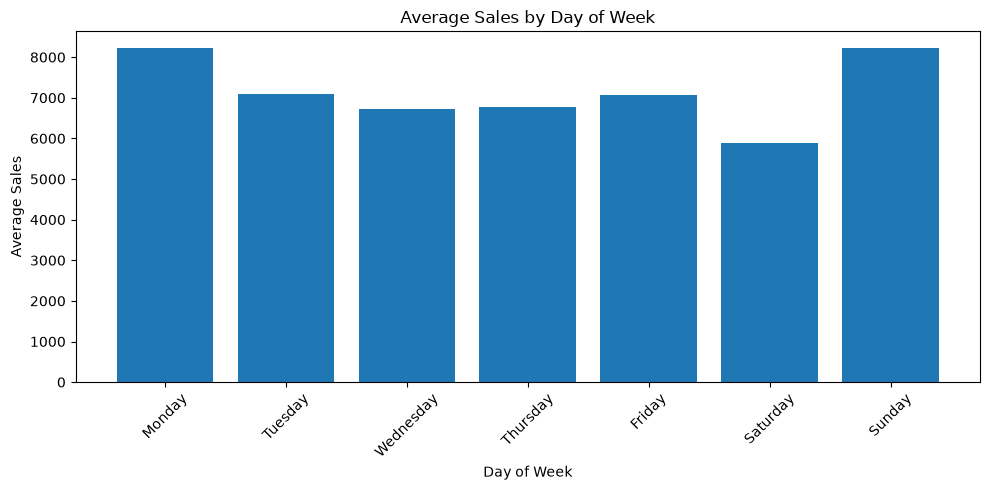

In [34]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_sales["DayOfWeek"],
    weekday_sales["Sales"]
)

plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.title("Average Sales by Day of Week")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [36]:
train["StateHoliday"] = train["StateHoliday"].astype(str)

In [37]:
train[["Date", "Store", "Sales", "Promo"]].head()

,Date,Store,Sales,Promo
0,2015-07-31,1,5263,1
1,2015-07-31,2,6064,1
2,2015-07-31,3,8314,1
3,2015-07-31,4,13995,1
4,2015-07-31,5,4822,1


In [38]:
promo_sales = (
    train.groupby("Promo")["Sales"]
    .mean()
    .reset_index()
)

promo_sales

,Promo,Sales
0,0,4406.050805
1,1,7991.152046


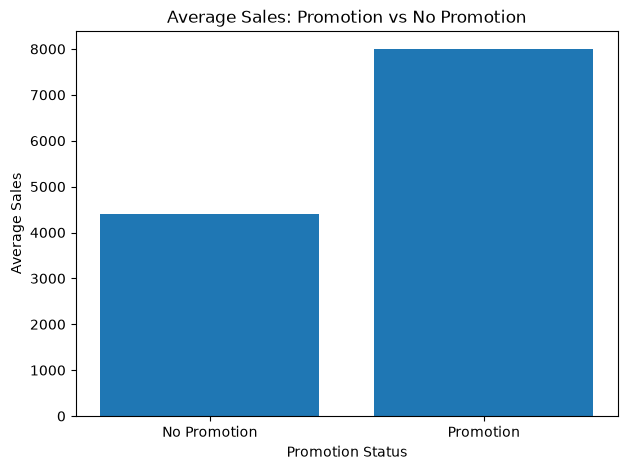

In [39]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["No Promotion", "Promotion"],
    promo_sales["Sales"]
)

plt.xlabel("Promotion Status")
plt.ylabel("Average Sales")
plt.title("Average Sales: Promotion vs No Promotion")

plt.show()

### Promotion Effect Observation

Average sales are noticeably higher on days with promotions
than on days without promotions. This suggests that promotion
status may be a useful feature for demand forecasting.

This comparison shows an association and does not by itself prove
that promotions caused the increase in sales.

In [40]:
store_sales = (
    df.groupby("Store")["Sales"]
    .mean()
    .reset_index()
)

store_sales.head()

,Store,Sales
0,1,4759.096031
1,2,4953.900510
2,3,6942.568678
3,4,9638.401786
4,5,4676.274711


In [41]:
store_sales["Sales"].describe()

count     1115.000000
mean      6934.208449
std       2383.911051
min       2703.736573
25%       5322.299969
50%       6589.948470
75%       7964.200644
max      21757.483418
Name: Sales, dtype: float64

In [42]:
top_stores = (
    store_sales
    .sort_values("Sales", ascending=False)
    .head(15)
)

top_stores

,Store,Sales
816,817,21757.483418
261,262,20718.515924
1113,1114,20666.562500
250,251,19123.068036
841,842,18574.795820
512,513,18179.089286
561,562,17969.556263
787,788,17961.914541
382,383,17294.716667
755,756,16574.816431


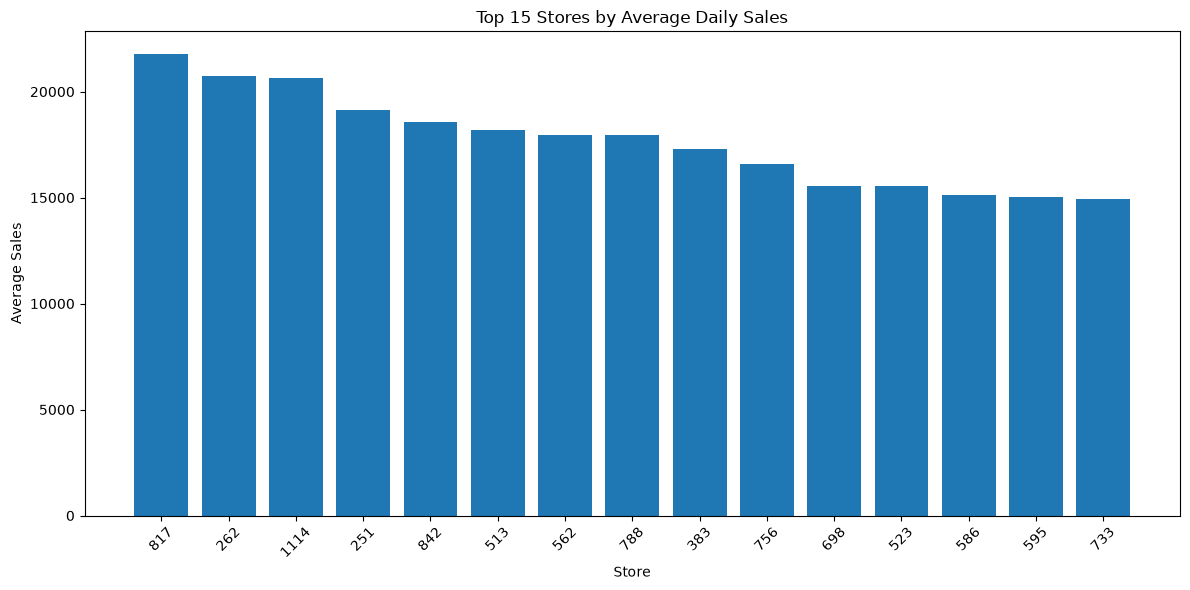

In [43]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_stores["Store"].astype(str),
    top_stores["Sales"]
)

plt.xlabel("Store")
plt.ylabel("Average Sales")
plt.title("Top 15 Stores by Average Daily Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Day 3 — EDA Findings

## Key Findings

### 1. Sales Distribution
Daily sales are right-skewed, with most observations concentrated in the lower-to-middle sales range and a smaller number of high-sales observations.

### 2. Daily Sales Trend
Total daily sales fluctuate substantially over time, with recurring drops and occasional high-demand spikes.

### 3. Monthly Seasonality
Average sales vary across months. Sales increase toward November and December, with December showing the highest average sales.

### 4. Weekday Effect
Average sales vary across days of the week, indicating a potential weekly seasonal pattern.

### 5. Promotion Effect
Average sales are noticeably higher on promotion days than on non-promotion days. This suggests that promotion status may be useful for demand forecasting.

### 6. Store Differences
Average sales vary significantly across stores. This indicates that stores have different demand levels and should be considered separately in forecasting and inventory decisions.

## Overall Conclusion

The EDA shows that demand is influenced by time patterns, promotions, and store-level differences. These findings will guide the feature engineering and forecasting stages of StockSense.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/processed/store_daily_sales.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Store", "Date"])

df["lag_1"] = df.groupby("Store")["Sales"].shift(1)

df[["Store", "Date", "Sales", "lag_1"]].head(10)

,Store,Date,Sales,lag_1
0,1,2013-01-02,5530,NaN
1,1,2013-01-03,4327,5530.0
2,1,2013-01-04,4486,4327.0
3,1,2013-01-05,4997,4486.0
4,1,2013-01-07,7176,4997.0
5,1,2013-01-08,5580,7176.0
6,1,2013-01-09,5471,5580.0
7,1,2013-01-10,4892,5471.0
8,1,2013-01-11,4881,4892.0
9,1,2013-01-12,4952,4881.0


In [4]:
df["lag_1"] = df.groupby("Store")["Sales"].shift(1)

df[["Store", "Date", "Sales", "lag_1"]].head(10)

,Store,Date,Sales,lag_1
0,1,2013-01-02,5530,NaN
1,1,2013-01-03,4327,5530.0
2,1,2013-01-04,4486,4327.0
3,1,2013-01-05,4997,4486.0
4,1,2013-01-07,7176,4997.0
5,1,2013-01-08,5580,7176.0
6,1,2013-01-09,5471,5580.0
7,1,2013-01-10,4892,5471.0
8,1,2013-01-11,4881,4892.0
9,1,2013-01-12,4952,4881.0


In [5]:
df["lag_7"] = df.groupby("Store")["Sales"].shift(7)
df["lag_14"] = df.groupby("Store")["Sales"].shift(14)
df["lag_30"] = df.groupby("Store")["Sales"].shift(30)

df[["Store", "Date", "Sales", "lag_1", "lag_7", "lag_14", "lag_30"]].head(35)

,Store,Date,Sales,lag_1,lag_7,lag_14,lag_30
0,1,2013-01-02,5530,NaN,NaN,NaN,NaN
1,1,2013-01-03,4327,5530.0,NaN,NaN,NaN
2,1,2013-01-04,4486,4327.0,NaN,NaN,NaN
3,1,2013-01-05,4997,4486.0,NaN,NaN,NaN
4,1,2013-01-07,7176,4997.0,NaN,NaN,NaN
5,1,2013-01-08,5580,7176.0,NaN,NaN,NaN
6,1,2013-01-09,5471,5580.0,NaN,NaN,NaN
7,1,2013-01-10,4892,5471.0,5530.0,NaN,NaN
8,1,2013-01-11,4881,4892.0,4327.0,NaN,NaN
9,1,2013-01-12,4952,4881.0,4486.0,NaN,NaN


In [6]:
df["rolling_7"] = (
    df.groupby("Store")["Sales"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df[["Store", "Date", "Sales", "lag_1", "rolling_7"]].tail(15)

,Store,Date,Sales,lag_1,rolling_7
844377,1115,2015-07-15,6039,7562.0,6841.714286
844378,1115,2015-07-16,6590,6039.0,6970.428571
844379,1115,2015-07-17,7874,6590.0,7069.000000
844380,1115,2015-07-18,7264,7874.0,7381.571429
844381,1115,2015-07-20,6083,7264.0,7584.428571
844382,1115,2015-07-21,5074,6083.0,7430.000000
844383,1115,2015-07-22,5342,5074.0,6640.857143
844384,1115,2015-07-23,6150,5342.0,6323.714286
844385,1115,2015-07-24,5816,6150.0,6339.571429
844386,1115,2015-07-25,6897,5816.0,6229.000000


In [7]:
df["rolling_14"] = (
    df.groupby("Store")["Sales"]
      .transform(lambda x: x.shift(1).rolling(14).mean())
)

df[["Store", "Date", "Sales", "rolling_7", "rolling_14"]].tail(15)

,Store,Date,Sales,rolling_7,rolling_14
844377,1115,2015-07-15,6039,6841.714286,7323.071429
844378,1115,2015-07-16,6590,6970.428571,6968.285714
844379,1115,2015-07-17,7874,7069.000000,6824.000000
844380,1115,2015-07-18,7264,7381.571429,6836.357143
844381,1115,2015-07-20,6083,7584.428571,6865.357143
844382,1115,2015-07-21,5074,7430.000000,6770.428571
844383,1115,2015-07-22,5342,6640.857143,6665.500000
844384,1115,2015-07-23,6150,6323.714286,6582.714286
844385,1115,2015-07-24,5816,6339.571429,6655.000000
844386,1115,2015-07-25,6897,6229.000000,6649.000000


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Store", "Date"])

df[["Store", "Date", "Sales"]].head(20)

,Store,Date,Sales
0,1,2013-01-02,5530
1,1,2013-01-03,4327
2,1,2013-01-04,4486
3,1,2013-01-05,4997
4,1,2013-01-07,7176
5,1,2013-01-08,5580
6,1,2013-01-09,5471
7,1,2013-01-10,4892
8,1,2013-01-11,4881
9,1,2013-01-12,4952


In [10]:
store_1 = df[df["Store"] == 1].copy()

store_1 = store_1.sort_values("Date")

store_1.head()

,Store,Date,Sales,lag_1,lag_7,lag_14,lag_30,rolling_7,rolling_14
0,1,2013-01-02,5530,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-03,4327,5530.0,NaN,NaN,NaN,NaN,NaN
2,1,2013-01-04,4486,4327.0,NaN,NaN,NaN,NaN,NaN
3,1,2013-01-05,4997,4486.0,NaN,NaN,NaN,NaN,NaN
4,1,2013-01-07,7176,4997.0,NaN,NaN,NaN,NaN,NaN


In [11]:
train_data = store_1.iloc[:-30]
test_data = store_1.iloc[-30:]

print("Training data:", train_data.shape)
print("Testing data:", test_data.shape)

Training data: (751, 9)
Testing data: (30, 9)


In [12]:
# Naive forecast
test_data = test_data.copy()

last_train_sales = train_data["Sales"].iloc[-1]

test_data["naive_prediction"] = last_train_sales

test_data[["Date", "Sales", "naive_prediction"]].head(10)

,Date,Sales,naive_prediction
751,2015-06-27,4019,3317
752,2015-06-29,5197,3317
753,2015-06-30,5735,3317
754,2015-07-01,5223,3317
755,2015-07-02,5558,3317
756,2015-07-03,4665,3317
757,2015-07-04,4797,3317
758,2015-07-06,4359,3317
759,2015-07-07,3650,3317
760,2015-07-08,3797,3317


In [13]:
# Seasonal Naive: use sales from 7 days earlier

test_data = test_data.copy()

test_data["seasonal_naive_prediction"] = (
    store_1["Sales"].shift(7).loc[test_data.index]
)

test_data[[
    "Date",
    "Sales",
    "seasonal_naive_prediction"
]].head(10)

,Date,Sales,seasonal_naive_prediction
751,2015-06-27,4019,4202.0
752,2015-06-29,5197,4097.0
753,2015-06-30,5735,3846.0
754,2015-07-01,5223,3762.0
755,2015-07-02,5558,3346.0
756,2015-07-03,4665,3533.0
757,2015-07-04,4797,3317.0
758,2015-07-06,4359,4019.0
759,2015-07-07,3650,5197.0
760,2015-07-08,3797,5735.0


In [15]:
from sklearn.metrics import mean_absolute_error

naive_mae = mean_absolute_error(
    test_data["Sales"],
    test_data["naive_prediction"]
)

seasonal_naive_mae = mean_absolute_error(
    test_data["Sales"],
    test_data["seasonal_naive_prediction"]
)

print("Naive MAE:", naive_mae)
print("Seasonal Naive MAE:", seasonal_naive_mae)

Naive MAE: 1223.5666666666666
Seasonal Naive MAE: 1148.8333333333333
